<a href="https://colab.research.google.com/github/ted-chang80/AIFFEL_quest_eng/blob/main/LLM_Application/LLM05/Day4_AgenticAI_Code_3_Autogen_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Last modified : 2026.03
작성 : 박광석(모두의연구소, https://www.linkedin.com/in/andkspark) , 2025.03


AutoGen은 Microsoft에서 개발한 멀티 에이전트 프레임워크로,
여러 개의 LLM 기반 에이전트들이 역할을 나누고 상호작용하며 협업적으로 문제를 해결할 수 있도록 설계된 오픈소스 시스템입니다! AutoGen은 다음의 특징을 가지고 있습니다.  

🧠 대화 기반의 워크플로우 구성  
에이전트 간 메시지 기반 커뮤니케이션을 통해, 사용자가 정의한 목표에 따라 작업을 진행합니다.

⚙️ 역할 기반 설계  
각 에이전트는 ‘코드 작성자’, ‘검토자’, ‘실행자’ 등 구체적인 역할을 갖고, 협업 구조를 자유롭게 정의할 수 있습니다.

🔁 루프 기반 상호 피드백 구조  
하나의 에이전트가 출력한 결과를 다른 에이전트가 검토하고 피드백하며, 여러 라운드에 걸쳐 개선된 결과를 도출합니다.

🔌 LLM/툴 통합 유연성  
OpenAI, Azure, HuggingFace 등 다양한 LLM API를 연결할 수 있고, Python 코드 실행이나 외부 시스템 연동 또한 지원합니다.

위 내용을 버그 수정 프로세스의 예시를 들어 다시 설명해보겠습니다.

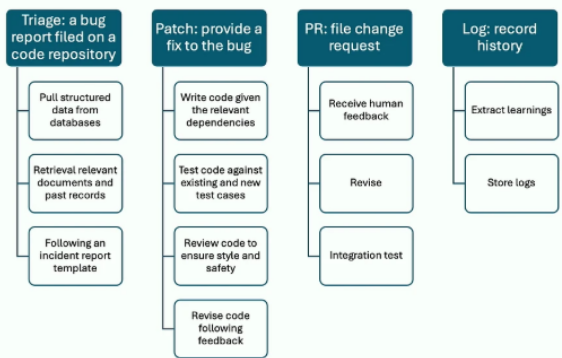

다음 버그 수정 워크플로우가 Autogen의 동작 방식을 잘 보여줍니다! 작업을 단위로 분해하고, 각각을 에이전트에 할당하여 수행하는 방식을 보여줍니다. 전체 워크플로우는 네 단계로, 각 세부 작업은 서로 다른 역할을 가진 에이전트가 맡아 병렬적이고 협력적으로 수행합니다.

1. Triage (버그 분류) 단계,

하나의 에이전트가 관련 데이터를 데이터베이스에서 추출하고,

다른 에이전트는 과거 사례 및 문서를 검색하며,

또 다른 에이전트는 정형화된 사고 보고서를 작성합니다.

2. Patch (버그 수정) 단계,

한 에이전트가 종속성에 맞춰 코드를 작성하고,

또 다른 에이전트는 테스트 케이스 기반으로 기능 검증을 수행합니다.

코드 스타일과 안정성을 리뷰하는 에이전트,

피드백을 반영해 코드를 수정하는 에이전트가 순차적으로 협업합니다.

3. PR (변경 요청) 단계,

한 에이전트가 PR에 대한 피드백을 수집하고,

또 다른 에이전트는 수정을 진행한 후,

통합 테스트를 담당하는 에이전트가 후속 검증을 수행합니다.

4. Log (기록) 단계,

한 에이전트가 학습 가능한 인사이트를 추출하고,

다른 에이전트는 결과를 로그로 저장합니다.

이처럼 AutoGen은 작업을 세분화하고 역할 기반의 에이전트를 조정하여, 사람의 개입 없이도 복잡한 엔지니어링 프로세스를 자동화할 수 있도록 지원합니다.

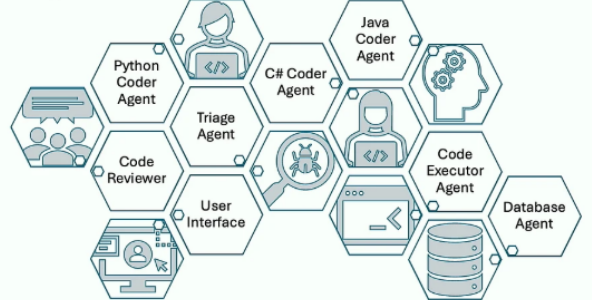

Autogen은 위에 설명했던 여러 에이전트를 내부적으로 구현, 가져다 쓸 수 있는 사용자 편의성을 제공하며, 사용자가 필요에 따라 에이전트와 도구를 직접 정의할 수도 있습니다!

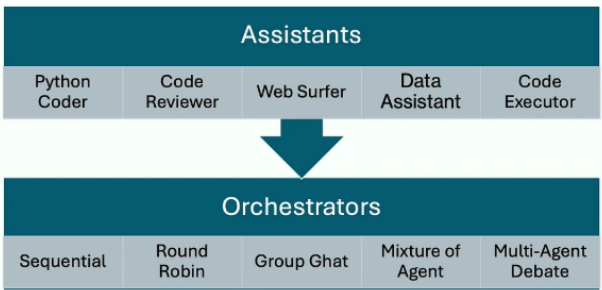

Autogen은 여러 형태로 에이전트간 소통할 수 있는 오케스트레이터를 함께 지원합니다.  
자세한 동작 방식은 다음 튜토리얼 - MultiAgent에서 소개해드릴게요!  

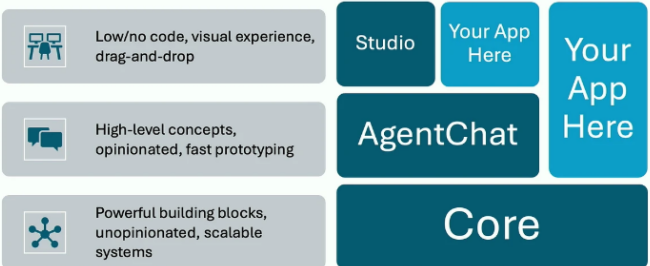

Autogen은 다음의 계층적 아키텍쳐를 가지고 있으며, 목표에 따라 선택하여 사용할 수 있습니다!   

🧱1. Core: 확장성과 유연성을 위한 기반 계층
AutoGen의 Core는 모듈화된 구성요소로 이루어진 핵심 빌딩 블록입니다.
사용자가 직접 시스템을 구성하고, 확장성과 통제력을 갖춘 커스터마이징 가능한 멀티 에이전트 프레임워크를 구축할 수 있도록 지원합니다.
낮은 수준의 제약으로, 복잡하고 대규모인 시스템을 구현하기에 적합합니다.  

💬 2. AgentChat: 빠른 프로토타이핑을 위한 고수준 API 계층
AgentChat은 다양한 역할의 에이전트를 생성하고, 이들 간의 대화 기반 협업 구조를 정의할 수 있는 고수준 프레임워크입니다.
의사결정 흐름을 텍스트 기반 인터페이스로 구성할 수 있어, 빠르게 실험하고 반복할 수 있는 환경을 제공합니다.
구조화된 대화형 시나리오 구현에 적합하며, 기본적인 에이전트 오케스트레이션 기능을 포함합니다.  

🎛️ 3. Studio: 비전문가도 사용할 수 있는 비주얼 에디터 계층
Studio는 시각화 중심의 UI를 제공하여 Low-code/No-code 환경에서 사용자가 직접 워크플로우를 설계하고 조정할 수 있게 해줍니다.
드래그 앤 드롭 방식으로 에이전트를 배치하고 연결할 수 있어, 개발자가 아니어도 쉽고 직관적으로 AutoGen 기반 앱을 구축할 수 있습니다.  
  
요약하자면,

Core → 확장성과 유연성 중심 (전문 개발자용)  
AgentChat → 실험과 구성 간소화 (AI 개발자/연구자용)  
Studio → 직관적인 시각 툴 (비개발자용)  
  
가 되겠습니다!

이번 튜토리얼은 AgentChat으로 진행됩니다!

### Step 0 : 설치와 준비  
Autogen 설치 및 API 키를 등록하도록 합니다.

In [1]:
!pip install autogen
!pip install -U "autogen-agentchat"
!pip install "autogen-ext[openai]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.3/119.3 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.9/101.9 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.4/331.4 kB 28.3 MB/s eta 0:00:00


In [3]:
import os

In [4]:
import os

# 현재 작업 경로 확인
current_path = os.getcwd()
print(f"현재 경로: {current_path}")

# 현재 경로의 파일 및 폴더 목록 확인
files = os.listdir(current_path)
print(f"파일 목록: {files}")

현재 경로: /content
파일 목록: ['.config', 'sample_data']


In [5]:
from autogen_agentchat.agents import AssistantAgent
from autogen_agentchat.conditions import TextMentionTermination
from autogen_ext.models.openai import OpenAIChatCompletionClient
from autogen_agentchat.messages import TextMessage

API KEY는 관리에 유의하시기 바랍니다!

In [6]:
from google.colab import userdata
OPENAI_API_KEY = userdata.get('OPENAI_KEY')


AutoGen은 복잡한 워크플로우를 가능하게 하는 오픈 소스 프레임워크로, 에이전트(agent)라는 개념을 중심으로 구성되어 있습니다!  
에이전트는 메시지를 주고받으며, 대형 언어 모델(LLM)이나 코드 실행기, 인간의 입력 등 다양한 구성 요소를 통해 응답을 생성할 수 있고, 외부 함수나 도구를 호출하여 특정 작업을 수행할 수 있도록 지원합니다.

### Step 1 : 에이전트 정의하기
Autogen에서는 이름과 시스템 메세지, 그리고 model client 만으로
매우 간편하게 에이전트를 정의할 수 있습니다!
  
model client는 "에이전트가 LLM(예: GPT-4)이랑 대화할 수 있게 해주는 연결 다리" 입니다. 다양한 모델의 API간의 다른 모델 호출 방식을 Autogen 코드 내에서 통일된 방식으로 접근할 수 있게 해줍니다.  
  
실습 코드에서 사용하는 OpenAIChatCompletionClient 는 OpenAI의 모델, 혹은 OpenAI API와 호환을 제공하는 모델 (예 : Gemini) 을 사용할 수 있습니다.  
그 외에도 Azure OpenAI models 을 지원하는 AzureOpenAIChatCompletionClient, Claude 등의 Anthropic 모델 /  Ollema 을 지원하는 AnthropicChatCompletionClient / OllamaChatCompletionClient 가 있으며, semanticp-kernel 을 이용해 mistral, aws, huggingface의 모델을 사용할 수 있는 SKChatCompletionAdapter 도 지원합니다.




In [8]:
model_client=OpenAIChatCompletionClient(
    model="gpt-4o-mini",
    api_key = OPENAI_API_KEY)

In [9]:
agent = AssistantAgent(
    name="assistant",
    model_client=model_client,
    system_message="넌 정말 똑똑한 친구야!",
)

### Step 2 : 메세지 보내기

Autogen은 에이전트를 여럿 두고 대화를 주고받는 형태로 시스템을 구성합니다.  물론 유저 또한 에이전트와 대화를 주고받을 수 있습니다!  
단일 에이전트와 Message를 통하여 대화를 주고받아보도록 하겠습니다.

면밀한 관찰을 위해 해당 실습에서는 autogen을 비동기식 (async) 으로 사용합니다.비동기식으로 autogen을 사용할 경우, 지연상황을 발생시키지 않기 위해 CancellationToken을 함께 사용합니다.
  
CancellationToken은 autogen.core 라이브러리에 정의되어 있습니다.

In [10]:
from autogen_core import CancellationToken

메세지에는 source가 함께 표기됩니다. 이후 진행해볼 에이전트간의 대화에서는 메세지를 발신한 에이전트의 정보가 표시됩니다.

In [15]:
text_message = TextMessage(content="안녕 월드! AI와 함께 만들고 싶어.", source="User")
text_message

TextMessage(id='1d8a91e1-da05-4030-8b81-6aa8c0597607', source='User', models_usage=None, metadata={}, created_at=datetime.datetime(2026, 5, 30, 6, 34, 44, 659401, tzinfo=datetime.timezone.utc), content='안녕 월드! AI와 함께 만들고 싶어.', type='TextMessage')

정의한 메세지로 에이전트와 대화해보겠습니다.
on_messages 메소드를 사용하여 정의한 메세지를 주입합니다.

In [16]:
response = await agent.on_messages(
    [text_message], cancellation_token=CancellationToken()
)
response.chat_message

TextMessage(id='3463b8f4-7ca5-47fd-bfb1-9571c764a599', source='assistant', models_usage=RequestUsage(prompt_tokens=76, completion_tokens=33), metadata={}, created_at=datetime.datetime(2026, 5, 30, 6, 34, 51, 399750, tzinfo=datetime.timezone.utc), content='안녕하세요! AI와 함께 어떤 것을 만들고 싶으신가요? 아이디어나 프로젝트에 대해 말씀해 주시면 도와드릴게요!', type='TextMessage')

답변은 메세지 객체로 돌아오며, 멤버 변수 content에 접근하여 모델의 출력을 확인할 수 있습니다.

In [17]:
print("<USER> : ", text_message.content)
print("<ASSISTANT> : ", response.chat_message.content)

<USER> :  안녕 월드! AI와 함께 만들고 싶어.
<ASSISTANT> :  안녕하세요! AI와 함께 어떤 것을 만들고 싶으신가요? 아이디어나 프로젝트에 대해 말씀해 주시면 도와드릴게요!


### Step 3 : 툴 사용하기

Agent는 tool을 사용하여 작업을 수행할 수 있습니다.  
Autogen에서 내장형으로 graph RAG, Langchain, mcp, http 도구를 지원하며, 사용자가 tool을 함수로 정의하여 사용할 수도 있습니다.  
  
이 섹션에서는 사용자가 정의한 툴을 사용해보겠습니다.

In [18]:
from autogen_core.tools import FunctionTool

In [20]:
import re

async def calculate_expression_func(input_string : str) -> str:
    match = re.search(r'(\d+)\s*([x*/+-])\s*(\d+)', input_string)
    if match:
        num1 = int(match.group(1))
        operator = match.group(2)
        num2 = int(match.group(3))

        if operator == 'x' or operator == '*':
            result = num1 * num2
        elif operator == '/':
            result = num1 / num2
        elif operator == '+':
            result = num1 + num2
        elif operator == '-':
            result = num1 - num2

        result *= 100

        return result

    else:
        return None
        # 수식을 찾을 수 없는 경우도구 None 반환

연산 결과의 100배를 돌려주는 함수입니다..!  
함수 정의 후 도구를 생성해줍니다

In [28]:
# Define a tool that searches the web for information.
calculate_tool = FunctionTool(calculate_expression_func, description = "100배로 반환해주는 도구")

Tool을 생성하면 내부적으로 Schema를 자동으로 생성합니다. 반환은 string으로 수행합니다.  

In [29]:
calculate_tool.schema

{'name': 'calculate_expression_func',
 'description': '100배로 반환해주는 도구',
 'parameters': {'type': 'object',
  'properties': {'input_string': {'description': 'input_string',
    'title': 'Input String',
    'type': 'string'}},
  'required': ['input_string'],
  'additionalProperties': False},
 'strict': False}

어시스턴트에 도구를 쥐어주겠습니다!  
아래 정의한 것 처럼, [] 안에 사용할 도구를 넣어줍니다.

Reflect_on_tool_use 는 모델이 별개로 추론한 결과를 도구 사용 결과에 반영할 것인가를 결정합니다.

In [30]:
agent = AssistantAgent(
    name="assistant",
    model_client=model_client,
    tools=[calculate_tool],
#    reflect_on_tool_use  = True,

    system_message="값을 잘 계산해줘 ",
)

In [33]:
async def assistant_run() -> None:
    response = await agent.on_messages(
        [TextMessage(content="3 * 4 가 뭐야?", source="user")],
        cancellation_token=CancellationToken(),
    )
    print("Chat Message : ", response.chat_message)
    print("Chat Message : ", response.chat_message.content)

3 * 4 를 도구를 사용하여 연산한 값을 확인해봅시다!

In [34]:
await assistant_run()

Chat Message :  id='de9733c1-0815-4e9f-acd1-3273243110d0' source='assistant' models_usage=None metadata={} created_at=datetime.datetime(2026, 5, 30, 6, 50, 10, 869982, tzinfo=datetime.timezone.utc) content='1200' type='ToolCallSummaryMessage' tool_calls=[FunctionCall(id='call_IZKaEmM0PJYxkOVcODCu7Qvz', arguments='{"input_string":"3 * 4"}', name='calculate_expression_func')] results=[FunctionExecutionResult(content='1200', name='calculate_expression_func', call_id='call_IZKaEmM0PJYxkOVcODCu7Qvz', is_error=False)]
Chat Message :  1200


모델이 별개로 추론한 결과를 함께 반영하면 어떻게 될까요? 확인해봅시다!  
어떤점이 달라지는지 관찰해보세요 :D

### Step 4 : 팀으로 일하기

두 에이전트의 협업은 어떻게 이루어질까요?  
앞서 언급하였듯, 에이전트는 대화를 통해 메세지를 주고받습니다.  
그리고 받은 메세지를 기반으로 탑재된 llm을 통해 추론 후, 메세지를 다시 보내는 동작을 수행합니다.

In [36]:
from autogen_agentchat.conditions import ExternalTermination, TextMentionTermination
from autogen_agentchat.teams import RoundRobinGroupChat
from autogen_agentchat.ui import Console


시를 쓰는 시인 에이전트와, 쓴 시에 피드백을 돌려주는 비평가 에이전트의 대화를 살펴봅시다!  
비평가가 허가 "APPROVE" 할떄까지, 시인 에이전트는 계속 시를 작성해야 합니다.  

In [37]:
# Create the primary agent.
poet_agent = AssistantAgent(
    "primary",
    model_client=model_client,
    system_message="You are a helpful AI assistant.",
)

# Create the critic agent.
critic_agent = AssistantAgent(
    "critic",
    model_client=model_client,
    system_message="건설적인 피드백을 주세요! 당신의 피드백이 반영된 결과를 답변으로 받았을 때, 'APPROVE' 라는 말을 포함하여 회신해주세요",
)

# Define a termination condition that stops the task if the critic approves.
text_termination = TextMentionTermination("APPROVE")

에이전트의 대화 방식은 여러가지가 있는데요, 일단 Round robin 방식으로 대화를 나눠봅시다!  
Round robin 은 각 참가자가 돌아가며 대화를 나누는 방식입니다.  
Autogen 에서는 한 에이전트가 supervisor가 되서 다른 에이전트들이 작업을 잘 수행하는지 점검하는 MagenticOneGroupChat, 다음 에이전트를 선택하여 분기를 생성할 수 있는 SelectorGroupChat 등을 함께 지원합니다.  
자세한 내용은 [여기](https://microsoft.github.io/autogen/stable/reference/python/autogen_agentchat.teams.html)에서 확인하실 수 있습니다.

대화에 참여할 에이전트들을 팀으로 배정한 후, 대화를 진행시켜봅시다!  
앞서 선언한 대화 종료 조건을 포함하는 것을 잊지 마세요 :D

In [38]:
# Create a team with the primary and critic agents.
team = RoundRobinGroupChat([poet_agent, critic_agent], termination_condition=text_termination)

In [39]:
result = await team.run(task="봄에 잘 어울리는 사랑에 관한 짧은 시를 써줘")
print(result)

messages=[TextMessage(id='33c6e7e8-63b5-4884-b8d5-4f7a9eaa32a1', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2026, 5, 30, 6, 53, 13, 401784, tzinfo=datetime.timezone.utc), content='봄에 잘 어울리는 사랑에 관한 짧은 시를 써줘', type='TextMessage'), TextMessage(id='66502677-7660-425c-8798-bc55f408bdf8', source='primary', models_usage=RequestUsage(prompt_tokens=37, completion_tokens=101), metadata={}, created_at=datetime.datetime(2026, 5, 30, 6, 53, 15, 133911, tzinfo=datetime.timezone.utc), content='봄바람에 실려 오는  \n꽃잎의 속삭임,  \n너와 나의 눈빛에서  \n새싹이 피어나는 듯.  \n\n햇살은 따스히,  \n우리의 손을 감싸고,  \n사랑의 씨앗은  \n조용히 자라나는 봄.  \n\n풀밭에 누워  \n꿈꾸는 그 순간,  \n세상 모든 것들이  \n우리의 비밀을 숨겨.  ', type='TextMessage'), TextMessage(id='51df3a7d-4f4a-4ca6-a1af-caeaefb6434c', source='critic', models_usage=RequestUsage(prompt_tokens=178, completion_tokens=160), metadata={}, created_at=datetime.datetime(2026, 5, 30, 6, 53, 18, 124382, tzinfo=datetime.timezone.utc), content='아주 아름다운 시입니다! 봄의 느낌과 사랑의 감정을 잘 담아내셨고, 이미지와 

In [40]:
for message in result.messages:
    print("<소스 : ", message.source, ">" , message.content)

<소스 :  user > 봄에 잘 어울리는 사랑에 관한 짧은 시를 써줘
<소스 :  primary > 봄바람에 실려 오는  
꽃잎의 속삭임,  
너와 나의 눈빛에서  
새싹이 피어나는 듯.  

햇살은 따스히,  
우리의 손을 감싸고,  
사랑의 씨앗은  
조용히 자라나는 봄.  

풀밭에 누워  
꿈꾸는 그 순간,  
세상 모든 것들이  
우리의 비밀을 숨겨.  
<소스 :  critic > 아주 아름다운 시입니다! 봄의 느낌과 사랑의 감정을 잘 담아내셨고, 이미지와 감각을 통해 독자가 그 장면을 쉽게 그릴 수 있도록 했네요. 몇 가지 건설적인 피드백을 드리자면:

1. 구성을 조금 더 변형해 보세요. 중간에 한 가지 새로운 이미지를 추가한다면 더욱 다채로워질 것 같습니다.
2. 마지막 두 줄의 표현이 너무 좋지만, 조금 더 강렬한 결말을 제안해보는 것도 좋을 듯합니다.

이러한 점을 고려하신다면 더욱 풍성한 시가 될 것 같아요! 다음 번 결과물에서 이런 사항들이 반영된다면 정말 기대하겠습니다. 

APPROVE


가끔 한번에 APPROVE를 받는 경우도 보이네요!    
어떤 경우에 챗이 종료가 되는지는 결과의 stop_reason 멤버 변수로 확인할 수 있습니다!

In [41]:
result.stop_reason

"Text 'APPROVE' mentioned"

### Step 5 : 콘솔로 출력해보기

메세지를 따로 받아서 조작할 필요가 없는 경우 console을 활용하는 것도 간편합니다  

In [42]:
await team.reset()  # Reset the team for a new task.
await Console(team.run_stream(task="봄에 잘 어울리는 사랑에 관한 짧은 시를 써줘"))  # Stream the messages to the console.

---------- TextMessage (user) ----------
봄에 잘 어울리는 사랑에 관한 짧은 시를 써줘
---------- TextMessage (primary) ----------
봄바람에 새싹이 피고  
햇살 가득한 이 순간,  
당신과 나, 손을 맞잡고  
서로의 눈빛에 사랑을 담아.

연못의 물결처럼 출렁이며  
우리의 마음도 소리 없이 뛰네,  
벚꽃이 흩날리는 길을 걸으며  
사랑의 이야기를 속삭여요.  

너와 나, 이 봄날에  
영원히 함께할 꿈을 꿉니다.  
새로운 시작은 언제나  
사랑으로 물들어 가죠.
---------- TextMessage (critic) ----------
아주 아름답고 감성적인 시입니다! 특히 봄의 느낌과 사랑의 감정을 잘 표현하고 있습니다. 다음과 같은 점에서 조금 더 발전할 수 있을 것 같아요:

1. **이미지의 다양성**: 여러 가지 봄의 이미지나 상징을 추가하면 더욱 풍부한 감성을 전달할 수 있을 것 같습니다. 예를 들어, 꽃, 새, 비 또는 아침의 이슬 등을 언급해보세요.

2. **리듬과 운율**: 전체적으로 좋은 흐름을 가지고 있지만, 몇 군데에서 리듬이 끊기는 느낌이 있습니다. 같은 길이의 구문을 유지한다면 더욱 부드럽게 읽힐 것 같습니다.

3. **감정의 다각화**: 사랑의 여러 측면(설렘, 행복, 그리움 등)을 조금 더 세분화하여 추가해보면, 독자들에게 전하는 감정이 더욱 깊어질 수 있습니다.

이런 요소들을 반영해보시면 더욱 매력적인 시로 발전할 것 같습니다. 좋은 작업 이어가세요! 

시의 수정된 버전을 받으면 'APPROVE'라고 응답하겠습니다.


TaskResult(messages=[TextMessage(id='a74b1905-8dba-4472-8212-01fa1f868c44', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2026, 5, 30, 6, 54, 22, 676490, tzinfo=datetime.timezone.utc), content='봄에 잘 어울리는 사랑에 관한 짧은 시를 써줘', type='TextMessage'), TextMessage(id='5448dd1d-8350-4abe-9537-ed08029b3205', source='primary', models_usage=RequestUsage(prompt_tokens=37, completion_tokens=129), metadata={}, created_at=datetime.datetime(2026, 5, 30, 6, 54, 24, 600653, tzinfo=datetime.timezone.utc), content='봄바람에 새싹이 피고  \n햇살 가득한 이 순간,  \n당신과 나, 손을 맞잡고  \n서로의 눈빛에 사랑을 담아.\n\n연못의 물결처럼 출렁이며  \n우리의 마음도 소리 없이 뛰네,  \n벚꽃이 흩날리는 길을 걸으며  \n사랑의 이야기를 속삭여요.  \n\n너와 나, 이 봄날에  \n영원히 함께할 꿈을 꿉니다.  \n새로운 시작은 언제나  \n사랑으로 물들어 가죠.', type='TextMessage'), TextMessage(id='665e10fd-a5a3-4133-b67b-46760de42b11', source='critic', models_usage=RequestUsage(prompt_tokens=206, completion_tokens=254), metadata={}, created_at=datetime.datetime(2026, 5, 30, 6, 54, 28, 138352, tzinfo=datetime.timezone.utc

출력이 어떻게 되는지 확인하셨나요?  
아래 같이 나오는 TaskResult의 경우, await Console(team.run_stream()) 이 반환하는 값을 받아주는 변수를 선언한다면 출력되지 않습니다.  

### Step 6 : Human in the loop

유저 또한 UserProxyAgent로 에이전트간의 대화에 참여할 수 있습니다!  


In [43]:
from autogen_agentchat.agents import UserProxyAgent

In [44]:
user_proxy = UserProxyAgent("user_proxy", input_func=input)

대화 종료를 위해 종료 조건을 설정해봅시다  
위에 설정한대로, 대화를 마치기 위해서는 APPROVE를, 피드백을 주고 싶다면 원하는 명령을 입력하세요!

In [45]:
# Create a team with the primary and critic agents.
team = RoundRobinGroupChat([poet_agent, user_proxy], termination_condition=text_termination)

In [46]:
stream = team.run_stream(task="봄에 잘 어울리는 사랑에 관한 짧은 시를 써줘")

In [47]:
await Console(stream)  # Stream the messages to the console.

---------- TextMessage (user) ----------
봄에 잘 어울리는 사랑에 관한 짧은 시를 써줘
---------- TextMessage (primary) ----------
봄의 햇살 아래 너와 나,  
꽃봉오리처럼 잠들어 있던 사랑이  
조금씩 피어나네.

부드러운 바람이 우리의 속삭임을  
이어주며  
다정한 눈빛에 마음이 걸려.

봄비 내리는 날,  
한 우산 아래 너와 나,  
서로의 온기로 세상을 잊고  
햇살이 다시 비추는 그날까지.
Enter your response: 
---------- TextMessage (user_proxy) ----------

---------- TextMessage (primary) ----------
봄의 향기 가득한 날,  
너와 나, 손을 맞잡고  
작은 꽃잎 한 송이처럼  
사랑이 피어나는 순간.

푸른 잔디 위에 앉아  
서로의 웃음소리에 마음이 가벼워져  
햇살처럼 따스한 이 기분,  
영원히 기억하고 싶어.

봄바람 속에 살랑이는  
우리의 이야기가  
꽃처럼 만개하길,  
사랑이란 이름으로.
Enter your response: 사랑
---------- TextMessage (user_proxy) ----------
사랑
---------- TextMessage (primary) ----------
사랑은 따스한 봄날의 햇살처럼,  
마음에 스며드는 부드러운 온기.  
서로의 눈빛 속에 숨겨진 이야기,  
행복과 아픔을 함께 나누는 길.

산뜻한 꽃잎의 속삭임처럼  
조용히 다가와 마음을 흔들고,  
비 오는 날 우산을 나누며  
서로의 진심을 대화로 엮어가.

사랑은 때로는 무겁고,  
때로는 가벼운 기분처럼  
서로의 존재가 있어  
더욱 빛나는 이 순간들.  

세상의 모든 순간이  
너와 나의 사랑으로  
같이 피어나는 봄이 되길,  
영원히 함께하길 소망해.
Enter your response: 여름
---------- TextMessage (user_proxy) ---

TaskResult(messages=[TextMessage(id='c1daa262-f172-4b7d-b59f-5a3911c1f634', source='user', models_usage=None, metadata={}, created_at=datetime.datetime(2026, 5, 30, 6, 56, 31, 462900, tzinfo=datetime.timezone.utc), content='봄에 잘 어울리는 사랑에 관한 짧은 시를 써줘', type='TextMessage'), TextMessage(id='bcdf33b0-a544-4727-a5c9-2f4441343291', source='primary', models_usage=RequestUsage(prompt_tokens=193, completion_tokens=99), metadata={}, created_at=datetime.datetime(2026, 5, 30, 6, 56, 33, 134545, tzinfo=datetime.timezone.utc), content='봄의 햇살 아래 너와 나,  \n꽃봉오리처럼 잠들어 있던 사랑이  \n조금씩 피어나네.\n\n부드러운 바람이 우리의 속삭임을  \n이어주며  \n다정한 눈빛에 마음이 걸려.\n\n봄비 내리는 날,  \n한 우산 아래 너와 나,  \n서로의 온기로 세상을 잊고  \n햇살이 다시 비추는 그날까지.', type='TextMessage'), UserInputRequestedEvent(id='54b9f62b-c01a-48f3-bdfd-71ec9ade0f19', source='user_proxy', models_usage=None, metadata={}, created_at=datetime.datetime(2026, 5, 30, 6, 56, 33, 136452, tzinfo=datetime.timezone.utc), request_id='37b8f3dc-abc7-4437-b065-05dcb0592665', content='', type='Use

수고하셨습니다!